In [9]:
import torch
import torch.nn as nn
import hdbscan
from sklearn.metrics import silhouette_score, adjusted_rand_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.decomposition import PCA
import os
import sys
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, PROJECT_ROOT)


from src.data.load_cifar100 import get_cifar100_loaders, create_and_load_subset
from src.models.autoencoder import Autoencoder
from src.data.load_cifar10 import get_cifar10_loaders
from src.models.cmae import CMAE
from src.models.masked_autoencoder import MAE

# Load pretrained model

In [10]:
def load_trained_model(model_path, model_type='autoencoder'):
    """
    Wczytanie wytrenowanego modelu

    Args:
        model_path: Ścieżka do pliku .pt
         model_type: "autoencoder', 'cmae' lub 'mae'

    Returns:
        model, checkpoint (słownik z metadanymi)
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Nie znaleziono pliku: {model_path}")

    # wczytanie checkpointa
    checkpoint = torch.load(model_path, map_location=device)

    # ładowanie modelu
    latent_dim = checkpoint.get('latent_dim', 256)  # domyślnie 256
    if model_type.lower() == 'cmae':
        model = CMAE(latent_dim=latent_dim).to(device)
    elif model_type.lower() == 'mae':
        model = MAE(latent_dim=latent_dim).to(device)
    elif model_type.lower() == 'autoencoder':
        model = Autoencoder(latent_dim=latent_dim).to(device)
    else:
        raise ValueError("model_type musi być: 'cmae', 'mae' lub 'autoencoder'")

    # ładowanie wag
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    print(f"Model załadowany")
    print(f"Epoka: {checkpoint['epoch']}")
    print(f"Train Loss: {checkpoint['train_loss']:.6f}")
    print(f"Val Loss: {checkpoint['val_loss']:.6f}")
    print(f"Latent Dim: {latent_dim}\n")

    return model, checkpoint






# Ekstrakcja cech

In [11]:
def extract_features(model, dataloader):
    """
    Wyciąga wektory cech z encodera

    Args:
        model: Autoencoder, MAE lub CMAE
        dataloader: DataLoader z danymi

    Returns:
        features: numpy array [N, latent_dim]
        labels: numpy array [N]
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    all_features = []
    all_labels = []

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(dataloader):
            images = images.to(device)

            if hasattr(model, 'online_encoder'):
                # CMAE
                features = model.online_encoder(images)
            
            elif hasattr(model, 'encoder'):
                # MAE oraz Autoencoder (oba mają self.encoder)
                features = model.encoder(images)
            
            else:
                raise AttributeError("Model nie ma atrybutu 'encoder' ani 'online_encoder'")


            # flattenujemy cechy -- [B, D, 1, 1] -> [B, D]
            if len(features.size()) > 2:
                features = features.view(features.size(0), -1)
            # dostajemy tylko cechy
            # features = model.encode(images)  # [batch_size, latent_dim]
            if batch_idx == 0:  # sprawdzenie
                print(f"Features: {features.size()}")

            all_features.append(features.cpu().numpy())
            all_labels.append(labels.numpy())


    features = np.concatenate(all_features, axis=0)
    labels = np.concatenate(all_labels, axis=0) # do ocenienia klasteryzacji


    print(f"Wyciągnięto cechy: {features.shape}")
    # print(f"Klasy {labels[:5]}") #sprawdzenie

    return features, labels




# Klasteryzacja

In [12]:
def clustering(features, labels, n_clusters=10):
    """
    Klasteryzacja używając K-means i HDBSCAN
    
    Args:
        features: numpy array [N, latent_dim]
        labels: numpy array [N] - prawdziwe etykiety
        n_clusters: liczba klastrów dla K-means
    
    Returns:
        cluster_ids: numpy array [N] - przypisanie do klastrów (K-means)
        kmeans: obiekt KMeans
        metrics: słownik z metrykami K-means
        metrics_hdb: słownik z metrykami HDBSCAN
    """
    # # HDBSCAN
    # clusterer = hdbscan.HDBSCAN(
    #     min_cluster_size=n_clusters,
    #     min_samples=5,
    #     cluster_selection_method='eom',
    #     allow_single_cluster=True,
    #     metric='euclidean',
    #     algorithm='best',
    #     leaf_size=30
    # )
    # cluster_ids_hdb = clusterer.fit_predict(features)
    # 
    # K-means
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10, verbose=0)
    cluster_ids = kmeans.fit_predict(features)
    
    # Metryki K-means
    nmi = normalized_mutual_info_score(labels, cluster_ids)
    ari = adjusted_rand_score(labels, cluster_ids)
    
    metrics = {
        'nmi': nmi,
        'ari': ari,
        'n_clusters': n_clusters,
        'inertia': kmeans.inertia_
    }
    
    print("=== K-means ===")
    print(f"NMI (Normalized Mutual Information): {nmi:.4f}")
    print(f"ARI (Adjusted Rand Index): {ari:.4f}")
    print(f"Inertia: {kmeans.inertia_:.2f}\n")
    
    # # Metryki HDBSCAN
    # nmi_hdb = normalized_mutual_info_score(labels, cluster_ids_hdb)
    # ari_hdb = adjusted_rand_score(labels, cluster_ids_hdb)
    # n_clusters_hdb = len(set(cluster_ids_hdb)) - (1 if -1 in cluster_ids_hdb else 0)
    # n_noise = list(cluster_ids_hdb).count(-1)
    # 
    # metrics_hdb = {
    #     'nmi': nmi_hdb,
    #     'ari': ari_hdb,
    #     'n_clusters': n_clusters_hdb,
    #     'n_noise': n_noise
    # }
    # 
    # print(f"NMI (Normalized Mutual Information): {nmi_hdb:.4f}")
    # print(f"ARI (Adjusted Rand Index): {ari_hdb:.4f}")
    # print(f"Liczba znalezionych klastrów: {n_clusters_hdb}")
    # print(f"Liczba punktów noise: {n_noise}\n")
    
    return cluster_ids, kmeans, metrics

# Wizualizacja klastrów

In [13]:
def visualize_clusters(features, cluster_ids, labels, save_path):
    """
    Pokazanie klastrow w 2D (PCA)
    """

    pca = PCA(n_components=2, random_state=42)
    features_2d = pca.fit_transform(features)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # klastry k-means
    scatter1 = ax1.scatter(features_2d[:, 0], features_2d[:, 1],
                          c=cluster_ids, cmap='tab10', alpha=0.6, s=3)
    ax1.set_title('K-means Clusters', fontsize=14, fontweight='bold')
    plt.colorbar(scatter1, ax=ax1, label='Cluster ID')

    # etykeity z datasetu
    scatter2 = ax2.scatter(features_2d[:, 0], features_2d[:, 1],
                          c=labels, cmap='tab10', alpha=0.6, s=3)
    ax2.set_title('True Labels', fontsize=14, fontweight='bold')
    plt.colorbar(scatter2, ax=ax2, label='Class ID')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    plt.close()

# Zapis wyników klasteryzacji do csv

In [15]:

def save_results_to_csv(cluster_ids, labels, metrics, save_dir):
    # opisanie każdego obrazu
    results_df = pd.DataFrame({
        'image_id': range(len(labels)),
        'true_label': labels,
        'cluster_id': cluster_ids,
        'correct_cluster': (labels == cluster_ids).astype(int)  # czy zgadza się
    })
    results_csv = os.path.join(save_dir, 'clustering_results.csv')
    results_df.to_csv(results_csv, index=False)


    summary_df = pd.DataFrame({
        'metric': ['NMI', 'ARI', 'n_clusters', 'inertia','n_samples'],
        'value': [
            f"{metrics['nmi']:.6f}",
            f"{metrics['ari']:.6f}",
            metrics['n_clusters'],
            f"{metrics['inertia']:.2f}",
            len(labels)
        ]
    })

    # Czy zrobic macierz pomyłek?


    return results_df, summary_df

# Ekstrakcja i klasteryzacja dla autoenkodera i cifar10

Model załadowany
Epoka: 44
Train Loss: 0.020622
Val Loss: 0.020325
Latent Dim: 256

Features: torch.Size([64, 256])
Wyciągnięto cechy: (10000, 256)
=== K-means ===
NMI (Normalized Mutual Information): 0.0963
ARI (Adjusted Rand Index): 0.0526
Inertia: 39446.18

NMI (Normalized Mutual Information): 0.0067
ARI (Adjusted Rand Index): 0.0001
Liczba znalezionych klastrów: 1
Liczba punktów noise: 9933



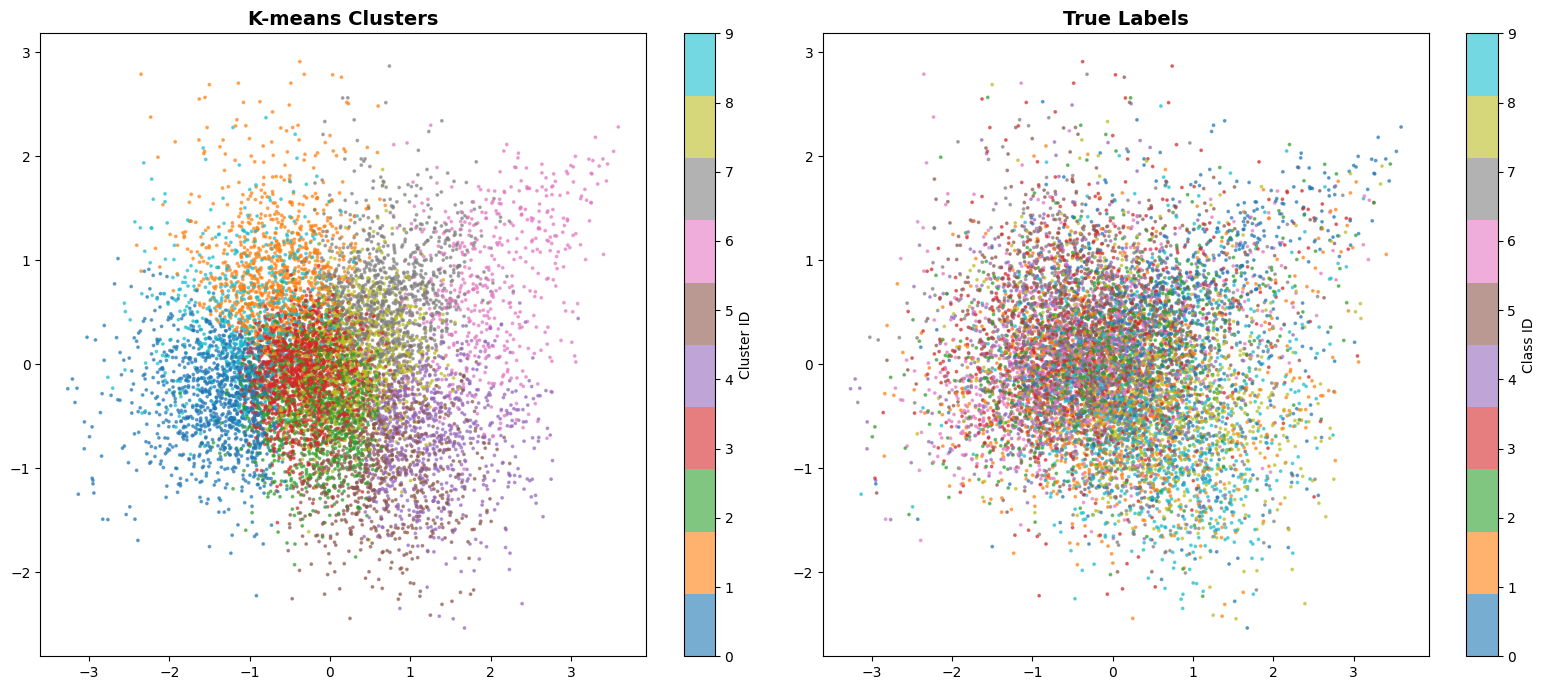

In [17]:
# ładowanie modelu
model_path= '../training_results/autoencoder/cifar10/autoencoder_cifar10_best_20260107_180431.pt'
model, checkpoint = load_trained_model(model_path, model_type='autoencoder')
# print(model)
# print(checkpoint)


# ładowanie danych testowych
batch_size = 64
_, _, test_loader = get_cifar10_loaders(batch_size=batch_size)
# print(f"Obrazów testowych: {len(test_loader)}")
# for batch_idx, (image, _) in enumerate(test_loader):
#     print(f"Batch {batch_idx} / {len(test_loader)}")


# wyciąganie cech
features, labels = extract_features(model, test_loader)

# klasteryzacja
n_clusters = 10
cluster_ids, kmeans, metrics, metrics_hdb = clustering(features, labels, n_clusters)

# zapis wynikow
BASE_DIR = os.getcwd()
save_dir = os.path.join(BASE_DIR, '../..', 'experiments', 'autoencoder','cifar10')
os.makedirs(save_dir, exist_ok=True)
results_df, summary_df = save_results_to_csv(cluster_ids, labels, metrics, save_dir)

# wizualizacja
vis_path = os.path.join(save_dir, 'clusters_visualization.png')
visualize_clusters(features, cluster_ids, labels, vis_path)


#  Ekstrakcja i klasteryzacja dla autoenkodera i cifar100

Model załadowany
Epoka: 50
Train Loss: 0.019298
Val Loss: 0.019483
Latent Dim: 256

Features: torch.Size([64, 256])
Wyciągnięto cechy: (10000, 256)


C:\Users\martu\Desktop\studia\magisterka\2sem\ml_projekt\venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Nie można odnaleźć określonego pliku
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\martu\Desktop\studia\magisterka\2sem\ml_projekt\venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\martu\Desktop\studia\magisterka\2sem\ml_projekt\venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\martu\AppData\Local\Programs\Python\Python311\Lib\s

NMI (Normalized Mutual Information): 0.2354
ARI (Adjusted Rand Index): 0.0231
Inertia: 30694.18



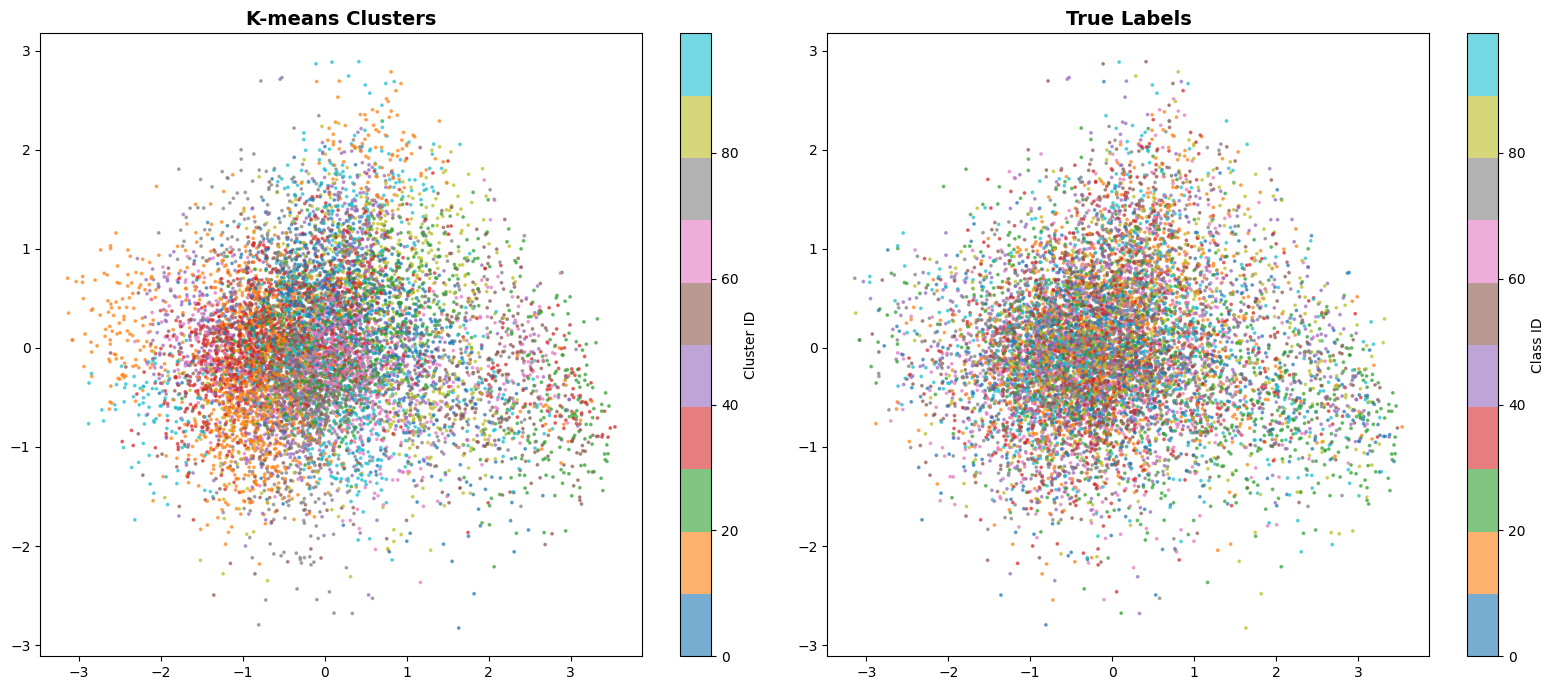

In [7]:
# ładowanie modelu
model_path= '../training_results/autoencoder/cifar100/autoencoder_cifar100_best_20260107_170204.pt'
model, checkpoint = load_trained_model(model_path, model_type='autoencoder')
# print(model)
# print(checkpoint)


# ładowanie danych testowych
batch_size = 64
_, _, test_loader = get_cifar100_loaders(batch_size=batch_size)
# print(f"Obrazów testowych: {len(test_loader)}")
# for batch_idx, (image, _) in enumerate(test_loader):
#     print(f"Batch {batch_idx} / {len(test_loader)}")


# wyciąganie cech
features, labels = extract_features(model, test_loader)

# klasteryzacja
n_clusters = 100
cluster_ids, kmeans, metrics = clustering(features, labels, n_clusters)

# zapis wynikow
BASE_DIR = os.getcwd()
save_dir = os.path.join(BASE_DIR, '../..', 'experiments', 'autoencoder','cifar100')
os.makedirs(save_dir, exist_ok=True)
results_df, summary_df = save_results_to_csv(cluster_ids, labels, metrics, save_dir)

# wizualizacja
vis_path = os.path.join(save_dir, 'clusters_visualization.png')
visualize_clusters(features, cluster_ids, labels, vis_path)


Model załadowany
Epoka: 213
Train Loss: 0.017373
Val Loss: 0.017545
Latent Dim: 256

Używam podanych klas: [3, 94]
Features: torch.Size([64, 256])
Wyciągnięto cechy: (200, 256)
=== K-means ===
NMI (Normalized Mutual Information): 0.0211
ARI (Adjusted Rand Index): 0.0240
Inertia: 1011.74



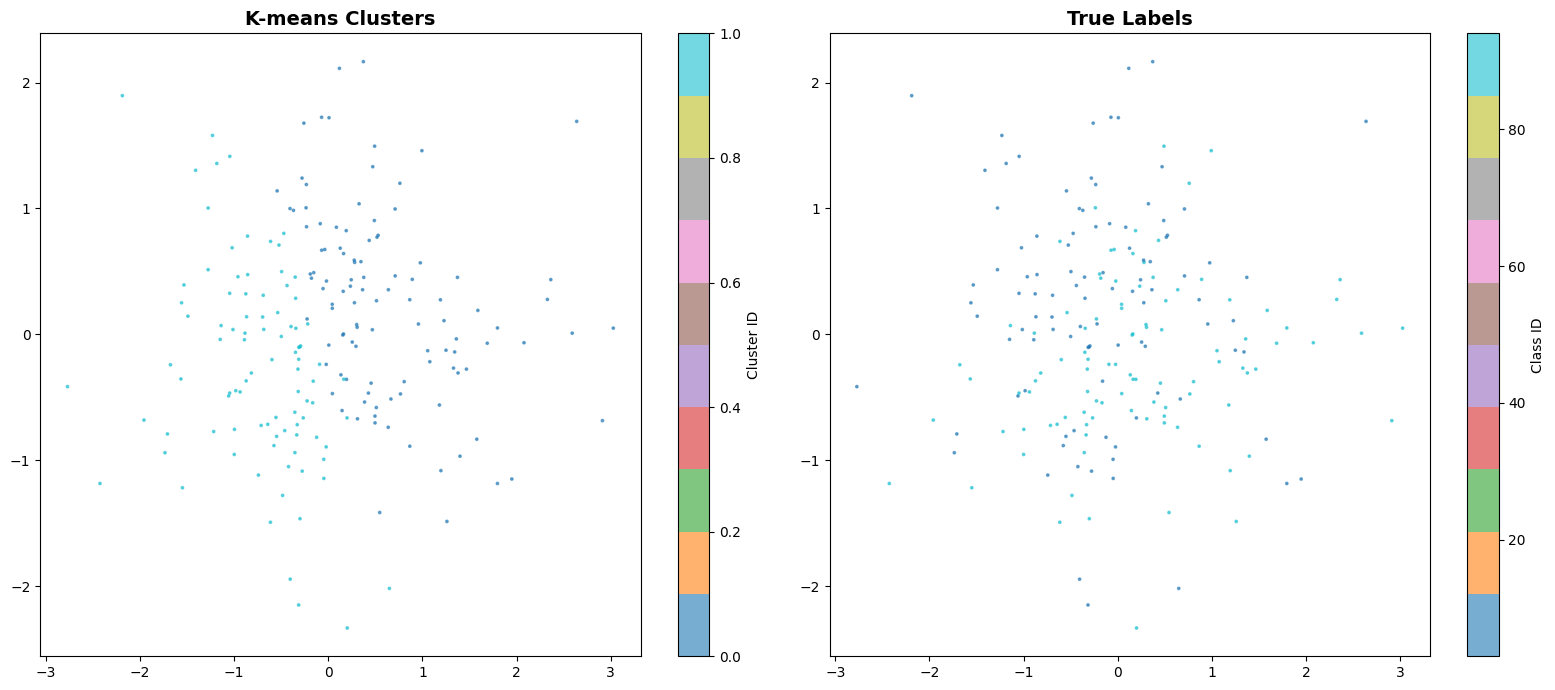

In [17]:
# ładowanie modelu
model_path= '../training_results/autoencoder/cifar100/autoencoder_cifar100_best_20260112_234254.pt'
model, checkpoint = load_trained_model(model_path, model_type='autoencoder')
# print(model)
# print(checkpoint)

selected_classes = checkpoint.get('selected_classes', None)
# print(model)
# print(checkpoint)


# ładowanie danych testowych
batch_size = 64
_, _, _, _, test_loader = create_and_load_subset(2, batch_size=batch_size, selected_classes=selected_classes)

# print(f"Obrazów testowych: {len(test_loader)}")
# for batch_idx, (image, _) in enumerate(test_loader):
#     print(f"Batch {batch_idx} / {len(test_loader)}")


# wyciąganie cech
features, labels = extract_features(model, test_loader)

# klasteryzacja
n_clusters = 2
cluster_ids, kmeans, metrics = clustering(features, labels, n_clusters)

# zapis wynikow
BASE_DIR = os.getcwd()
save_dir = os.path.join(BASE_DIR, '../..', 'experiments', 'autoencoder','cifar100')
os.makedirs(save_dir, exist_ok=True)
results_df, summary_df = save_results_to_csv(cluster_ids, labels, metrics, save_dir)

# wizualizacja
vis_path = os.path.join(save_dir, 'clusters_visualization.png')
visualize_clusters(features, cluster_ids, labels, vis_path)


#  Ekstrakcja i klasteryzacja dla MAE i cifar10

Model załadowany
Epoka: 41
Train Loss: 0.066288
Val Loss: 0.065836
Latent Dim: 256

Features: torch.Size([64, 256])
Wyciągnięto cechy: (10000, 256)
NMI (Normalized Mutual Information): 0.0705
ARI (Adjusted Rand Index): 0.0359
Inertia: 33781.43



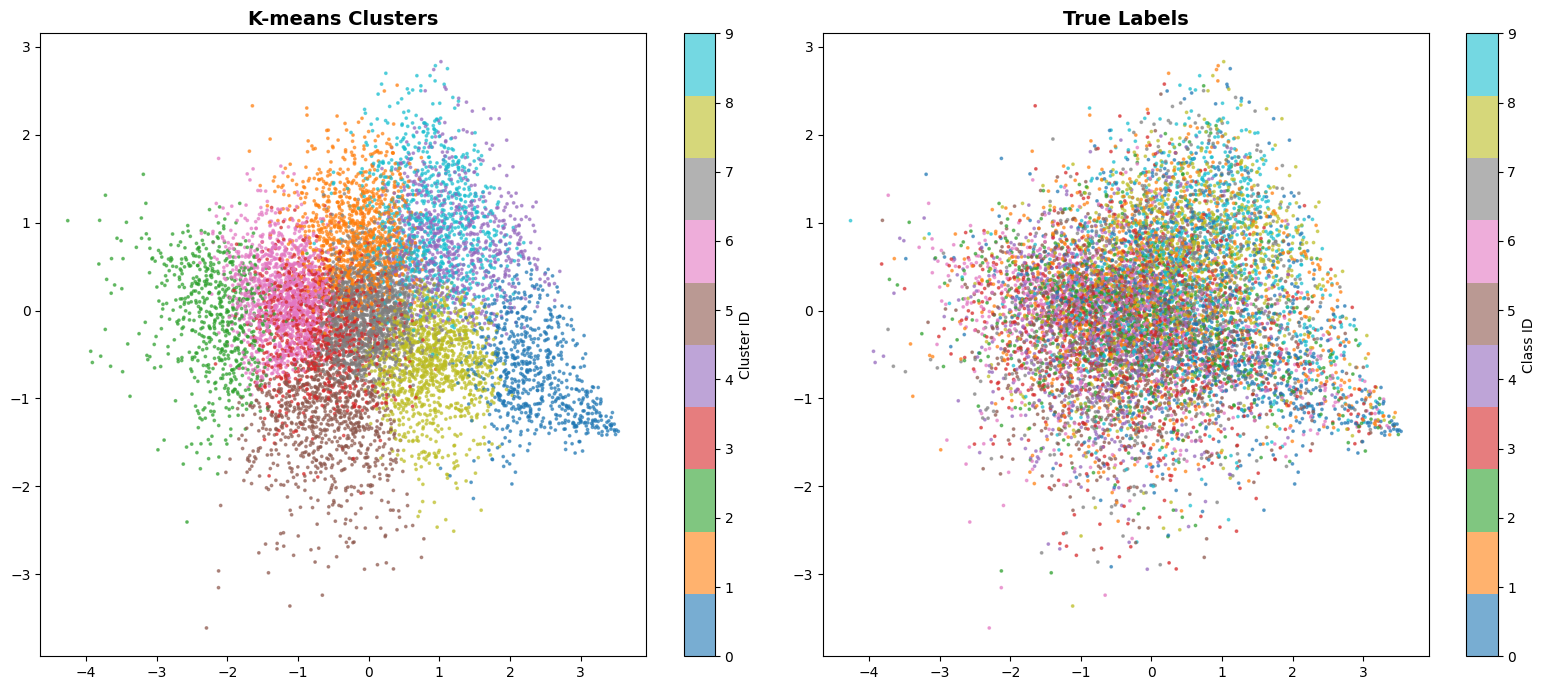

In [35]:
# ładowanie modelu
model_path= '../training_results/masked_autoencoder/cifar10/masked_autoencoder_cifar10_best_20260107_192113.pt'
model, checkpoint = load_trained_model(model_path, model_type='mae')
# print(model)
# print(checkpoint)


# ładowanie danych testowych
batch_size = 64
_, _, test_loader = get_cifar10_loaders(batch_size=batch_size)
# print(f"Obrazów testowych: {len(test_loader)}")
# for batch_idx, (image, _) in enumerate(test_loader):
#     print(f"Batch {batch_idx} / {len(test_loader)}")


# wyciąganie cech
features, labels = extract_features(model, test_loader)

# klasteryzacja
n_clusters = 10
cluster_ids, kmeans, metrics = clustering(features, labels, n_clusters)

# zapis wynikow
BASE_DIR = os.getcwd()
save_dir = os.path.join(BASE_DIR, '../..', 'experiments', 'masked_autoencoder','cifar10')
os.makedirs(save_dir, exist_ok=True)
results_df, summary_df = save_results_to_csv(cluster_ids, labels, metrics, save_dir)

# wizualizacja
vis_path = os.path.join(save_dir, 'clusters_visualization.png')
visualize_clusters(features, cluster_ids, labels, vis_path)


#  Ekstrakcja i klasteryzacja dla MAE i cifar100

Model załadowany
Epoka: 181
Train Loss: 0.059856
Val Loss: 0.059021
Latent Dim: 256

Features: torch.Size([64, 256])
Wyciągnięto cechy: (10000, 256)


C:\Users\martu\Desktop\studia\magisterka\2sem\ml_projekt\venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Nie można odnaleźć określonego pliku
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\martu\Desktop\studia\magisterka\2sem\ml_projekt\venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\martu\Desktop\studia\magisterka\2sem\ml_projekt\venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\martu\AppData\Local\Programs\Python\Python311\Lib\s

=== K-means ===
NMI (Normalized Mutual Information): 0.2140
ARI (Adjusted Rand Index): 0.0191
Inertia: 41427.46



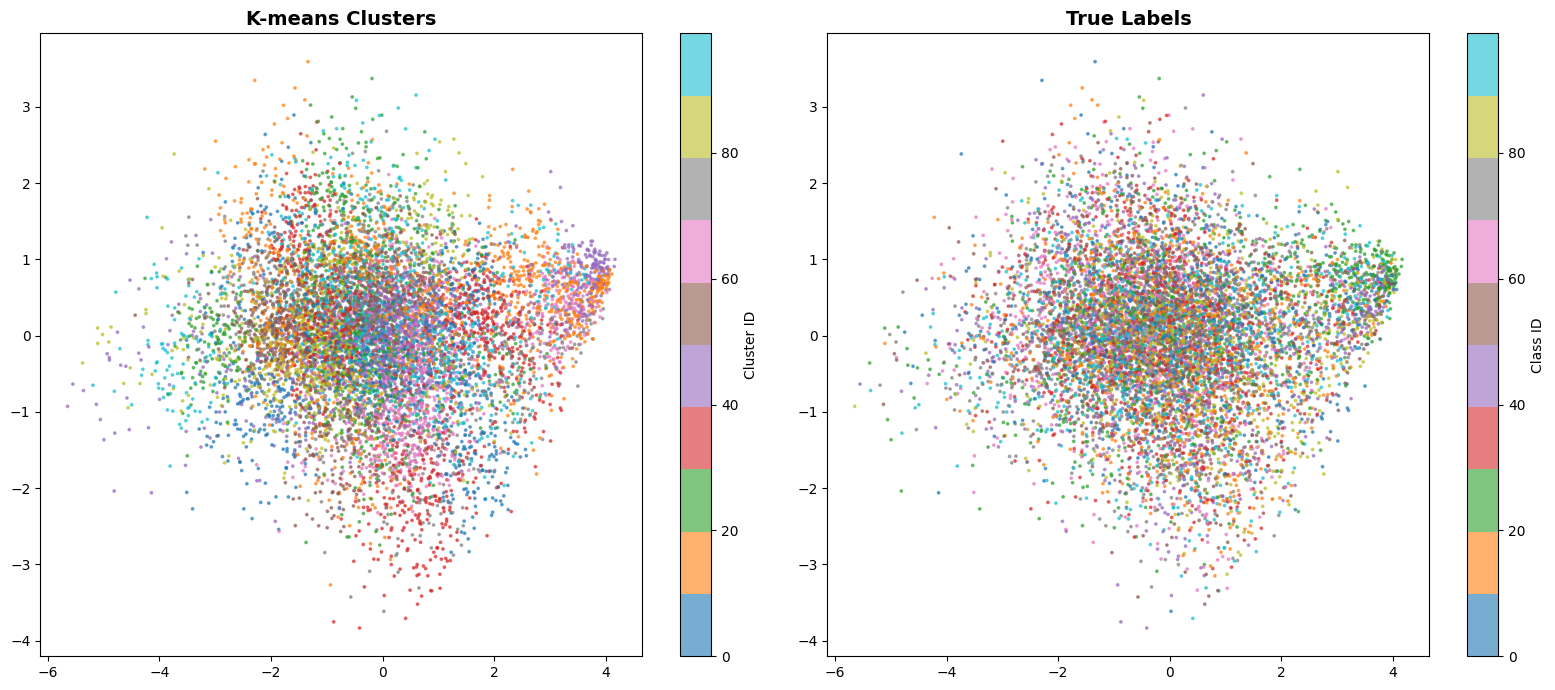

In [7]:
# ładowanie modelu
model_path= '../training_results/masked_autoencoder/cifar100/masked_autoencoder_cifar100_best_20260112_113108.pt'
model, checkpoint = load_trained_model(model_path, model_type='mae')
# print(model)
# print(checkpoint)


# ładowanie danych testowych
batch_size = 64
_, _, test_loader = get_cifar100_loaders(batch_size=batch_size)
# print(f"Obrazów testowych: {len(test_loader)}")
# for batch_idx, (image, _) in enumerate(test_loader):
#     print(f"Batch {batch_idx} / {len(test_loader)}")


# wyciąganie cech
features, labels = extract_features(model, test_loader)

# klasteryzacja
n_clusters = 100
cluster_ids, kmeans, metrics = clustering(features, labels, n_clusters)

# zapis wynikow
BASE_DIR = os.getcwd()
save_dir = os.path.join(BASE_DIR, '../..', 'experiments', 'masked_autoencoder','cifar100')
os.makedirs(save_dir, exist_ok=True)
results_df, summary_df = save_results_to_csv(cluster_ids, labels, metrics, save_dir)

# wizualizacja
vis_path = os.path.join(save_dir, 'clusters_visualization.png')
visualize_clusters(features, cluster_ids, labels, vis_path)


Model załadowany
Epoka: 171
Train Loss: 0.056839
Val Loss: 0.059416
Latent Dim: 256

Wylosowano nowe klasy: [81, 14]
Features: torch.Size([64, 256])
Wyciągnięto cechy: (200, 256)
=== K-means ===
NMI (Normalized Mutual Information): 0.0385
ARI (Adjusted Rand Index): 0.0481
Inertia: 946.69



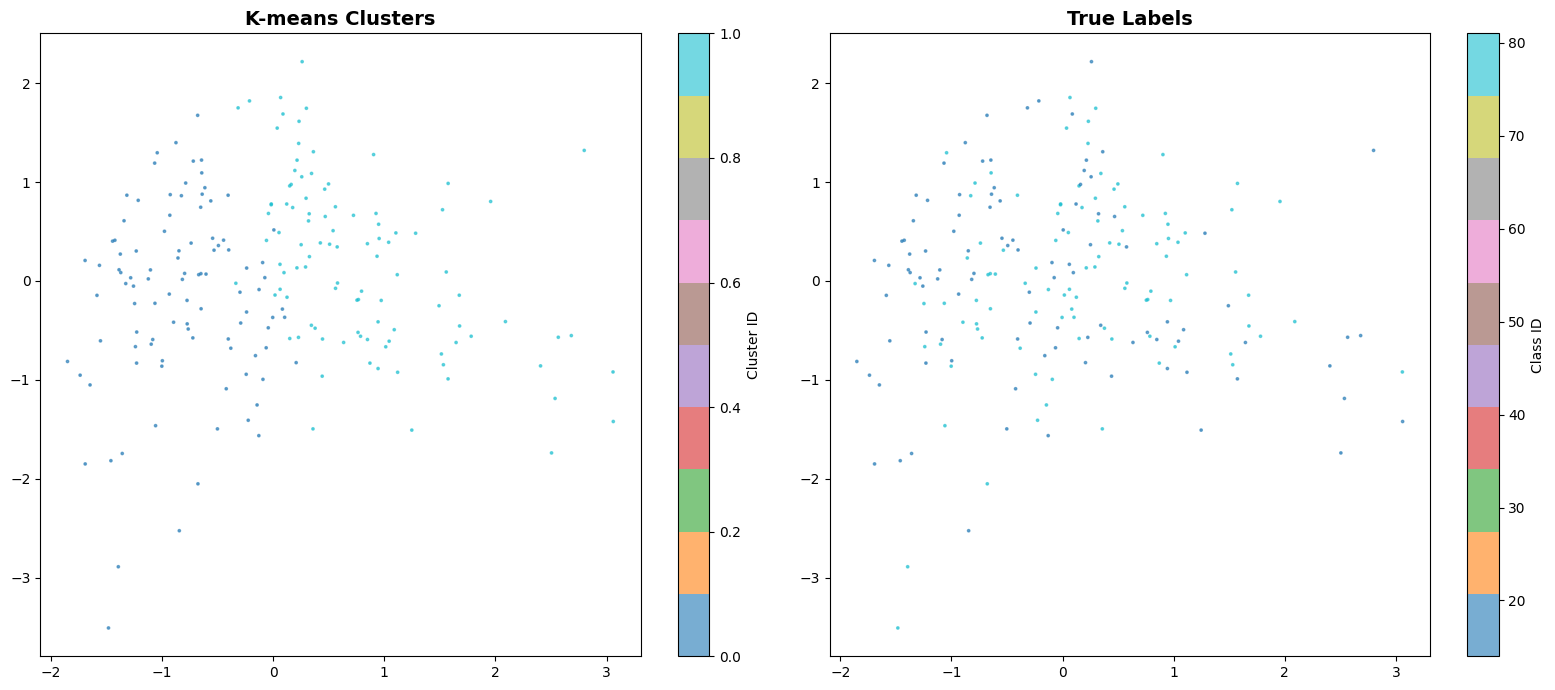

In [18]:
# ładowanie modelu
model_path= '../training_results/masked_autoencoder/cifar100/masked_autoencoder_cifar100_best_20260112_234816.pt'
model, checkpoint = load_trained_model(model_path, model_type='mae')
# print(model)
# print(checkpoint)

selected_classes = checkpoint.get('selected_classes', None)
# print(model)
# print(checkpoint)
# ładowanie danych testowych
batch_size = 64
_, _, _, _, test_loader = create_and_load_subset(2, batch_size=batch_size, selected_classes=selected_classes)

# print(f"Obrazów testowych: {len(test_loader)}")
# for batch_idx, (image, _) in enumerate(test_loader):
#     print(f"Batch {batch_idx} / {len(test_loader)}")


# wyciąganie cech
features, labels = extract_features(model, test_loader)

# klasteryzacja
n_clusters = 2
cluster_ids, kmeans, metrics = clustering(features, labels, n_clusters)

# zapis wynikow
BASE_DIR = os.getcwd()
save_dir = os.path.join(BASE_DIR, '../..', 'experiments', 'masked_autoencoder','cifar100')
os.makedirs(save_dir, exist_ok=True)
results_df, summary_df = save_results_to_csv(cluster_ids, labels, metrics, save_dir)

# wizualizacja
vis_path = os.path.join(save_dir, 'clusters_visualization.png')
visualize_clusters(features, cluster_ids, labels, vis_path)


# Ekstrakcja i klasteryzacja dla CMAE i cifar10

Model załadowany
Epoka: 45
Train Loss: 0.049636
Val Loss: 0.057030
Latent Dim: 256

Features: torch.Size([64, 256])
Wyciągnięto cechy: (10000, 256)
NMI (Normalized Mutual Information): 0.0759
ARI (Adjusted Rand Index): 0.0296
Inertia: 1390.01



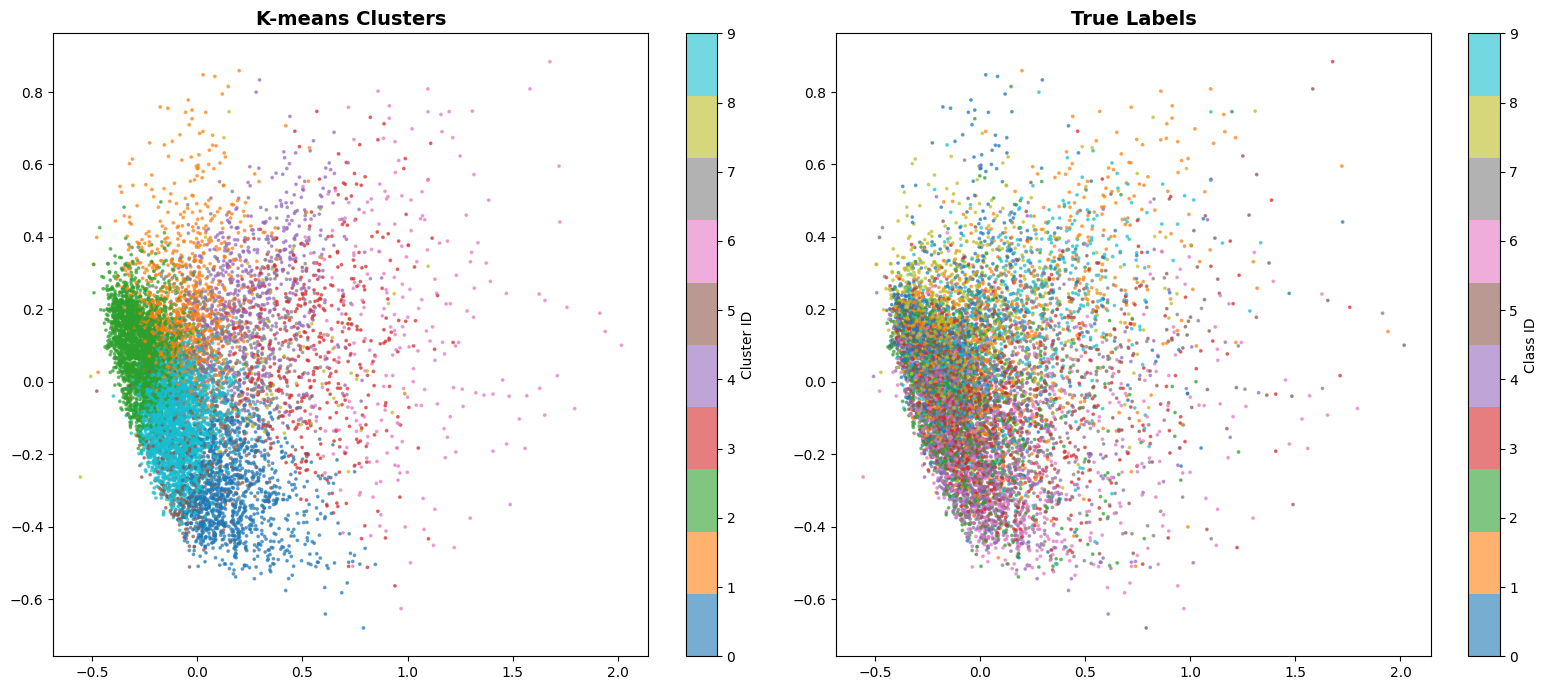

In [37]:
# ładowanie modelu
model_path= '../training_results/cmae/cifar10/cmae_cifar10_best_20260111_193204.pt'
model, checkpoint = load_trained_model(model_path, model_type='cmae')
# print(model)
# print(checkpoint)


# ładowanie danych testowych
batch_size = 64
_, _, test_loader = get_cifar100_loaders(batch_size=batch_size)
# print(f"Obrazów testowych: {len(test_loader)}")
# for batch_idx, (image, _) in enumerate(test_loader):
#     print(f"Batch {batch_idx} / {len(test_loader)}")


# wyciąganie cech
features, labels = extract_features(model, test_loader)

# klasteryzacja
n_clusters = 10
cluster_ids, kmeans, metrics = clustering(features, labels, n_clusters)

# zapis wynikow
BASE_DIR = os.getcwd()
save_dir = os.path.join(BASE_DIR, '../..', 'experiments', 'cmae','cifar10')
os.makedirs(save_dir, exist_ok=True)
results_df, summary_df = save_results_to_csv(cluster_ids, labels, metrics, save_dir)

# wizualizacja
vis_path = os.path.join(save_dir, 'clusters_visualization.png')
visualize_clusters(features, cluster_ids, labels, vis_path)


#  Ekstrakcja i klasteryzacja dla CMAE i cifar100

In [ ]:
# ładowanie modelu
model_path= '../training_results/cmae/cifar100/cmae_cifar100_best_20260111_155425.pt'
model, checkpoint = load_trained_model(model_path, model_type='cmae')
# print(model)
# print(checkpoint)


# ładowanie danych testowych
batch_size = 64
_, _, test_loader = get_cifar100_loaders(batch_size=batch_size)
# print(f"Obrazów testowych: {len(test_loader)}")
# for batch_idx, (image, _) in enumerate(test_loader):
#     print(f"Batch {batch_idx} / {len(test_loader)}")


# wyciąganie cech
features, labels = extract_features(model, test_loader)

# klasteryzacja
n_clusters = 10
cluster_ids, kmeans, metrics = clustering(features, labels, n_clusters)

# zapis wynikow
BASE_DIR = os.getcwd()
save_dir = os.path.join(BASE_DIR, '../..', 'experiments', 'cmae','cifar100')
os.makedirs(save_dir, exist_ok=True)
results_df, summary_df = save_results_to_csv(cluster_ids, labels, metrics, save_dir)

# wizualizacja
vis_path = os.path.join(save_dir, 'clusters_visualization.png')
visualize_clusters(features, cluster_ids, labels, vis_path)


RuntimeError: Error(s) in loading state_dict for Autoencoder:
	Missing key(s) in state_dict: "encoder.conv11.weight", "encoder.conv11.bias", "encoder.bn11.weight", "encoder.bn11.bias", "encoder.bn11.running_mean", "encoder.bn11.running_var", "encoder.conv12.weight", "encoder.conv12.bias", "encoder.bn12.weight", "encoder.bn12.bias", "encoder.bn12.running_mean", "encoder.bn12.running_var", "encoder.conv21.weight", "encoder.conv21.bias", "encoder.bn21.weight", "encoder.bn21.bias", "encoder.bn21.running_mean", "encoder.bn21.running_var", "encoder.conv22.weight", "encoder.conv22.bias", "encoder.bn22.weight", "encoder.bn22.bias", "encoder.bn22.running_mean", "encoder.bn22.running_var", "encoder.conv31.weight", "encoder.conv31.bias", "encoder.bn31.weight", "encoder.bn31.bias", "encoder.bn31.running_mean", "encoder.bn31.running_var", "encoder.conv32.weight", "encoder.conv32.bias", "encoder.bn32.weight", "encoder.bn32.bias", "encoder.bn32.running_mean", "encoder.bn32.running_var", "encoder.fc.w

Model załadowany
Epoka: 216
Train Loss: 0.092191
Val Loss: 0.122859
Latent Dim: 256

Używam podanych klas: [81, 14]
Features: torch.Size([64, 256])
Wyciągnięto cechy: (200, 256)
=== K-means ===
NMI (Normalized Mutual Information): 0.0759
ARI (Adjusted Rand Index): 0.0746
Inertia: 939.30



C:\Users\martu\Desktop\studia\magisterka\2sem\ml_projekt\venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Nie można odnaleźć określonego pliku
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\martu\Desktop\studia\magisterka\2sem\ml_projekt\venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\martu\Desktop\studia\magisterka\2sem\ml_projekt\venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\martu\AppData\Local\Programs\Python\Python311\Lib\s

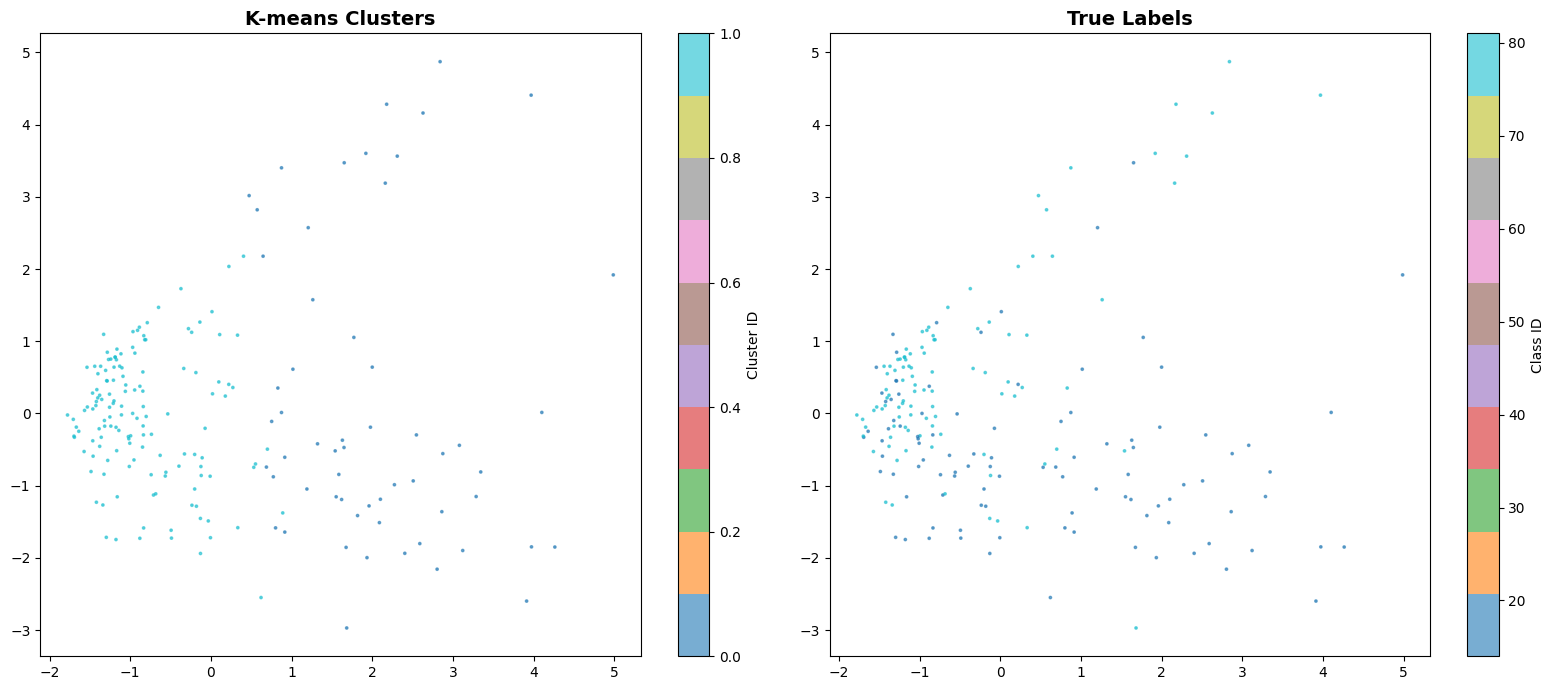

In [8]:
# ładowanie modelu
model_path= '../training_results/cmae/cifar100/cmae_cifar10_best_20260112_233713.pt'
model, checkpoint = load_trained_model(model_path, model_type='cmae')
selected_classes = checkpoint.get('selected_classes', None)
# print(model)
# print(checkpoint)


# ładowanie danych testowych
batch_size = 64
_, _, _, _, test_loader = create_and_load_subset(2, batch_size=batch_size, seed=42, selected_classes=selected_classes)

# print(f"Obrazów testowych: {len(test_loader)}")
# for batch_idx, (image, _) in enumerate(test_loader):
#     print(f"Batch {batch_idx} / {len(test_loader)}")


# wyciąganie cech
features, labels = extract_features(model, test_loader)

# klasteryzacja
n_clusters = 2
cluster_ids, kmeans, metrics = clustering(features, labels, n_clusters)

# zapis wynikow
BASE_DIR = os.getcwd()
save_dir = os.path.join(BASE_DIR, '../..', 'experiments', 'cmae','cifar100')
os.makedirs(save_dir, exist_ok=True)
results_df, summary_df = save_results_to_csv(cluster_ids, labels, metrics, save_dir)

# wizualizacja
vis_path = os.path.join(save_dir, 'clusters_visualization.png')
visualize_clusters(features, cluster_ids, labels, vis_path)
